In [1]:
# ==========================
# 1. Import libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Load the Clean Data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. Separate Features and Target
# We drop 'stress_level' to get X, and keep only 'stress_level' for y
X_train = train_df.drop(columns=['stress'])
y_train = train_df['stress']

X_test = test_df.drop(columns=['stress'])
y_test = test_df['stress']

In [4]:
# ==========================
# 3. Apply SMOTE to training data (optional)
# ==========================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE balancing:")
print(pd.Series(y_train_res).value_counts())


After SMOTE balancing:
0    329
1    329
2    329
Name: stress, dtype: int64


In [5]:
# ==========================
# 4. Train XGBoost model
# ==========================
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_train_res, y_train_res)
print("\n✅ Model Training Complete!")


✅ Model Training Complete!


In [6]:
# ==========================
# 5. Evaluate Model
# ==========================
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n==== Model Performance on Test Set ====")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


==== Model Performance on Test Set ====
Accuracy: 0.9708
F1-score: 0.9710

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.92      0.99      0.95        71
           2       0.99      0.95      0.97        94

    accuracy                           0.97       240
   macro avg       0.97      0.97      0.97       240
weighted avg       0.97      0.97      0.97       240



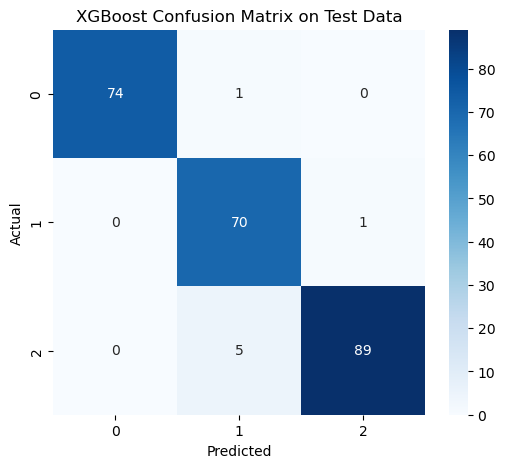

In [7]:
# ==========================
# 6. Confusion Matrix
# ==========================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix on Test Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
# ==========================
# 1. Import joblib and pandas
# ==========================
import joblib
import pandas as pd

# ==========================
# 2. Save your trained model
# ==========================
model_path = r"D:\AIhealthCoach\models\xgb_healthcoach_model.pkl"
joblib.dump(model, model_path)
print(f"✅ Model saved successfully at {model_path}")

# ==========================
# 3. Load the model later
# ==========================
loaded_model = joblib.load(model_path)
print("✅ Model loaded successfully!")

# ==========================
# 4. Example: Predict on new user input
# ==========================
# ⚠️ Use the same feature names and order as in your training dataset
X_new = pd.DataFrame([[ 
    3.5,    # sleep_hours (hours per night)
    4.0,    # meal_quality (scale 1–10)
    12.5,    # screen_time (hours/day)
    5.0,    # physical_activity (scale 1–10)
    8000,   # steps (steps per day)
    6.5     # mood (scale 1–10)
]], columns=['sleep_hours', 'meal_quality', 'screen_time', 'physical_activity', 'steps', 'mood'])

# Make prediction
y_pred_new = loaded_model.predict(X_new)

# ==========================
# 5. Map numeric prediction to stress level
# ==========================
class_mapping = {0: "Low Stress", 1: "Medium Stress", 2: "High Stress"}
predicted_label = class_mapping.get(int(y_pred_new[0]), "Unknown")

print("\nPredicted stress level class:", y_pred_new[0])
print("Predicted stress level:", predicted_label)


✅ Model saved successfully at D:\AIhealthCoach\models\xgb_healthcoach_model.pkl
✅ Model loaded successfully!

Predicted stress level class: 1
Predicted stress level: Medium Stress


In [10]:
X_new = pd.DataFrame([[ 
    8,    # sleep_hours (hours per night)
    8,    # meal_quality (scale 1–10)
    12.5,    # screen_time (hours/day)
    7,   # physical_activity (scale 1–10)
    1000,  # steps (steps per day)
    10   # mood (scale 1–10)
]], columns=['sleep_hours', 'meal_quality', 'screen_time', 'physical_activity', 'steps', 'mood'])

# Make prediction
y_pred_new = loaded_model.predict(X_new)

# ==========================
# 5. Map numeric prediction to stress level
# ==========================
class_mapping = {0: "Low Stress", 1: "Medium Stress", 2: "High Stress"}
predicted_label = class_mapping.get(int(y_pred_new[0]), "Unknown")

print("\nPredicted stress level class:", y_pred_new[0])
print("Predicted stress level:", predicted_label)


Predicted stress level class: 0
Predicted stress level: Low Stress
